<a href="https://colab.research.google.com/github/siddhigogri/SiddhiGogri_LP_Synapse26/blob/week2_ML/SynapseTask_LP_2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week Two**

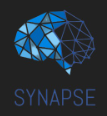



# Synapse Task 2A: Classification Foundations

Welcome back! In Task 1A, you explored regression and built gradient descent from scratch. In Task 1B, you classified data using K-Nearest Neighbors, saw why feature scaling is crucial, and hunted for the optimal $K$.

Now, in **Task 2A**, we take things up a notch with three proper classifiers: **Logistic Regression**, **Naive Bayes**, and **Decision Trees**. We will train, evaluate, and compare all three on the exact same customer churn dataset.

In the next notebook, **Task 2B: SVM & Ensembles**, we will build directly on this foundation with Support Vector Machines, GridSearchCV, tree pruning, and Ensembles (Bagging, Random Forests, AdaBoost, and XGBoost).

Chalo, let's get started!

## Part 1 — Data Preparation & Evaluation Foundations

Real-world data is messy. Columns have mixed types, missing values hide behind blank spaces, and categorical strings need to be converted to numbers before any algorithm can touch them.

In this section, we will load the IBM Telco Customer Churn dataset, uncover a sneaky data-quality trap, explore churn patterns, encode categorical features without leaking information, and set up strict evaluation metrics.

### Helpful Resources
- [One-Hot vs Label Encoding using Scikit-Learn](https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/) *(When to dummy vs when to label encode)*
- [Target Encoding Primer](https://www.geeksforgeeks.org/machine-learning/target-encoding/) *(Mean target replacement & why it leaks)*
- [Precision, Recall, and ROC Curves Explained](https://www.youtube.com/watch?v=Kdsp6soqA7o) *(A very clear visual guide to classification metrics)*

### Step 1.1: Mount Google Drive and Import Base Libraries

Let's mount Google Drive and import standard data analysis and visualization tools.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
# Hint: Use os.walk() or os.listdir() if you need to locate 'WA_Fn-UseC_-Telco-Customer-Churn.csv' in your Drive
# for root, dirs, files in os.walk('/content/drive'):
#     if 'WA_Fn-UseC_-Telco-Customer-Churn.csv' in files:
#         print(os.path.join(root, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

### Step 1.2: Load and Inspect the Dataset


We'll use the **Telco Customer Churn** dataset (originally IBM sample data, hosted on Kaggle):

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` and upload it to your Google Drive, same way you did for previous tasks. It has 7,043 rows and 21 columns — the target column is `Churn` (Yes/No).

In [ ]:
# Hint: pd.read_csv('/content/drive/MyDrive/.../WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Call .head() to see the first 5 rows
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Hint: Check column info, non-null counts, and datatypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Hint: View summary statistics of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Step 1.3: The Data-Quality Investigation

Take a closer look at `TotalCharges`. It represents total money billed to a customer, but notice its data type in `.info()`.

In [ ]:
# Hint: Check df['TotalCharges'].dtype and inspect a few sample values
df['TotalCharges'].dtype
df['TotalCharges'].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


**Question:** `TotalCharges` clearly represents money billed, yet pandas parsed it as an `object` (string). Why did pandas do this, and what happens if you try to pass string-formatted currency into a numerical classifier?  
**Answer:** You cant do numerical calculations like finding mean, sum, average on string so if we try to do any of these it will give an error.

### Step 1.4: Sanitizing `TotalCharges` & Handling Missing Values

When pandas loads a column with even a single blank space (`" "`), it defaults the whole column to text. We can force blank strings to become true `NaN` values using `pd.to_numeric(..., errors='coerce')`.

In [ ]:
# Hint: Use pd.to_numeric(df['TotalCharges'], errors='coerce') to convert the column
# Then count how many NaNs were introduced
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

**Question:** Look at how many `NaN` values were created out of the 7,043 total rows. Given the size of that count, would you drop those rows or impute them? What is your business justification? 🤔  
**Answer:** yes we can since 11 is very insignificant in front of 7043 other entries.

In [ ]:
# Hint: Drop the rows with NaN in TotalCharges using df.dropna(subset=['TotalCharges'], inplace=True)
# Verify the new shape of df
df.dropna(subset=['TotalCharges'], inplace=True)
df.shape

(7032, 21)

### Step 1.5: Exploratory Visualizations

Let's do some quick EDA to see how customer behaviors correlate with churn.

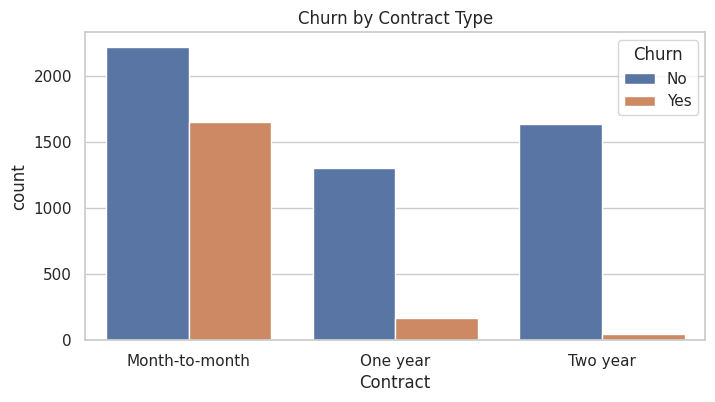

In [ ]:
# Hint: Use sns.countplot() with x='Contract' and hue='Churn'
# plt.figure(figsize=(8, 4))
# sns.countplot(...)
# plt.title("Churn by Contract Type")
# plt.show()
plt.figure(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

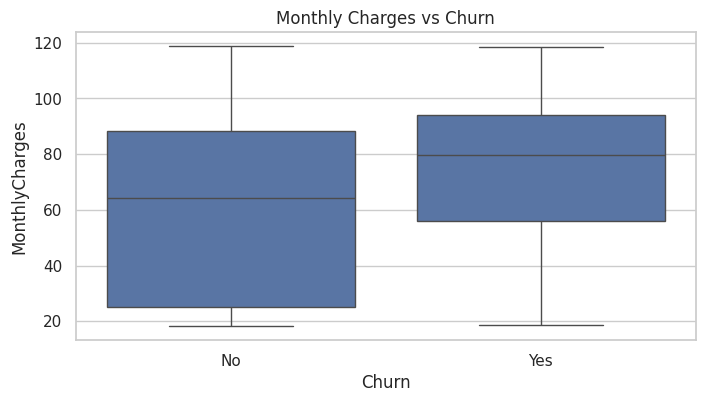

In [ ]:
# Hint: Use sns.boxplot() with x='Churn' and y='MonthlyCharges'
# plt.figure(figsize=(8, 4))
# sns.boxplot(...)
# plt.title("Monthly Charges vs Churn")
# plt.show()
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [ ]:
#more visulalisations that you might need

**Question:** Looking at the two plots above, what kind of customer profile is most at risk of churning? How do contract duration and monthly bill amounts factor into retention? 🤔  
**Answer:** From the countplot we can see that out of the people who are on month-to-month contract the split between them leaving or not leaving is nearly 40-45%. However, the number of people leaving after with a 2-year contract is negligible. From the boxplot, we see that the people who leave end up paying more on an average that th epeople who stay.

### Step 1.6: Feature Preprocessing & Encoding Strategies

Machine learning models require numerical inputs. We must convert categorical text columns into numbers:
- **Binary columns** (`Partner`, `Dependents`, `PhoneService`): Map directly to `0` and `1`.
- **Multi-category nominal columns** (`PaymentMethod`, `Contract`): Use **One-Hot Encoding** (`pd.get_dummies(..., drop_first=True)`).
- **Target Encoding**: Replaces each category with the average churn rate of that category:
  $$\hat{x}_c = \frac{1}{|S_c|}\sum_{i \in S_c} y_i$$
- **Arbitrary identifiers**: `customerID` has zero generalizable predictive value. Drop it first!

**Question:** Why does calculating Target Encoding on the entire dataset *before* train-test splitting cause serious data leakage? What would go wrong when evaluating on test data? 🤔  
**Answer:**

In [ ]:
# Hint: Drop the customerID column from df using df.drop(columns=['customerID']) if u need to give reason for the same if u do so ~~~
# df =
df.drop(columns=['customerID'],inplace=True)

**Answer:**

In [ ]:
# Hint: Convert the target column 'Churn' into binary 0 and 1
df['Churn'].unique()
df['Churn']=df['Churn'].map({'No':0,'Yes':1})
df['Churn'].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [ ]:
# Hint: Use pd.get_dummies(df, drop_first=True) to encode remaining categorical columns
# df_encoded = pd.get_dummies(...)
# print("Encoded shape:", df_encoded.shape)
df_encoded=pd.get_dummies(df,drop_first=True)
print("Encoded shape:", df_encoded.shape)

Encoded shape: (7032, 31)


In [ ]:
# Hint: Separate features into X (drop 'Churn') and target into y (df_encoded['Churn'])
# X =
# y =
X=df_encoded.drop(columns=['Churn'])
y=df_encoded['Churn']

In [ ]:
# Hint: from sklearn.model_selection import train_test_split
# Split into X_train, X_test, y_train, y_test using test_size=0.3, random_state=42, stratify=y
# X_train, X_test, y_train, y_test =
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Hint: from sklearn.preprocessing import StandardScaler
# Standardize continuous columns ['tenure', 'MonthlyCharges', 'TotalCharges']
# Remember: fit_transform() on X_train, but ONLY transform() on X_test!
# scaler =
# num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# X_train[num_cols] =
# X_test[num_cols] =
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Step 1.7: Evaluation Metrics Beyond Raw Accuracy

In an imbalanced dataset, raw accuracy is deceptive. If 73% of customers don't churn, a naive dummy model predicting "No" every time gets 73% accuracy while catching zero churners!

We use metrics derived from the **Confusion Matrix**:

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} \quad\quad \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

For every model evaluated in this notebook, you must call `confusion_matrix()` and `classification_report()`.

**Question:** In a telecom business trying to retain customers with promotional discounts, which is worse: a **False Positive** (offering a discount to someone who wasn't leaving) or a **False Negative** (missing a customer who cancels)? Why?
**Answer:** A false negative because even if i have given the discount, i still have the customer in my hands but loosing a customer completely can be more harmful than just loosing out on some part of the profit.

## Part 2 — Logistic Regression

Linear regression predicts continuous real values, which can produce nonsensical probabilities below 0 or above 1. Logistic Regression fixes this by squashing the linear output through the **Sigmoid function**:

$$p = \frac{1}{1 + e^{-(wx + b)}}$$

Instead of Mean Squared Error, it optimizes **Binary Cross-Entropy Loss**. The resulting gradient formula mirrors the MSE gradient you worked with in Task 1A: $\frac{1}{m} X^T (p - y)$.

### Helpful Resources
- [Logistic Regression Main Idea](https://youtu.be/yIYKR4sgzI8) *(StatQuest foundational overview)*
- [Logistic Regression Implementation](https://www.youtube.com/watch?v=n40hS9tQmcY) *(Quick code walkthrough)*
- [Geometric Intuition & Hyperplanes](https://florianhartl.com/logistic-regression-geometric-intuition.html) *(Decision boundaries in feature space)*
- [StatQuest: Logistic Regression Coefficients](https://youtu.be/vN5cNN2-HWE) *(Interpreting weights and log-odds)*
- [StatQuest: Maximum Likelihood Estimation](https://youtu.be/BfKanl1aSG0) *(This video covers the full MLE derivation — watch this to see where the loss comes from!)*
- [Optional Deep Dive: Logistic Regression](https://medium.com/@premvardhankumar/a-deep-understanding-of-logistic-regression-with-geometric-probabilistic-and-loss-minimization-2ced042bdcc7) *(Detailed equations written out)*

### Step 2.1: Scikit-Learn Logistic Regression

Let's train a baseline `LogisticRegression` classifier and print its complete classification diagnostics.

In [ ]:
# Hint: from sklearn.linear_model import LogisticRegression
# Instantiate with max_iter=1000, random_state=42, and fit on X_train, y_train
# logreg =
# logreg.fit(...)
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000,random_state=42)
logreg.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Hint: Use .predict() on X_test to get predicted labels
# y_pred_lr =
y_pred_lr = logreg.predict(X_test)

In [ ]:
# Hint: from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Print accuracy_score, confusion_matrix, and classification_report
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n",classification_report(y_test, y_pred_lr))

Accuracy: 0.8061611374407583

Confusion Matrix:
 [[1383  166]
 [ 243  318]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



### Step 2.2: Logistic Regression from Scratch

In Task 1A, you wrote linear regression with gradient descent. Now, complete the `LogisticRegression` class below. It follows the exact same skeleton, updated with the sigmoid transformation and a 0.5 decision threshold!

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate# initialize learning rate
        self.iterations = iterations# initialize iterations

    def fit(self, X, Y):
        self.m, self.n = df_encoded.shape# assign training data shape (rows, columns)
        self.W = # initialize weight vector of zeros of size n
        self.b = # initialize bias to 0
        self.X = # store X (convert to np.array if needed)
        self.Y = # store Y (convert to np.array if needed)

        for i in range(self.iterations):
            self.update_weights()
        return self

    def update_weights(self):
        # Hint: linear step z = self.X.dot(self.W) + self.b, then sigmoid(z) = 1 / (1 + np.exp(-z))
        Y_pred = # predicted probability using sigmoid
        dW = # (1/m) * X.T.dot(Y_pred - Y)
        db = # (1/m) * sum(Y_pred - Y)
        self.W = # gradient descent update (W - learning_rate * dW)
        self.b = # gradient descent update (b - learning_rate * db)
        return self

    def predict(self, X):
        # Hint: linear step z = X.dot(self.W) + self.b, then sigmoid, threshold at 0.5 to return 0 or 1
        return # return binary 0/1 array

SyntaxError: invalid syntax (3709999154.py, line 3)

In [ ]:
# Hint: Instantiate your scratch LogisticRegression, fit on X_train, predict on X_test, and print accuracy
# custom_logreg =


**Question:** What is fundamentally different about `predict()` here compared to the `predict()` method of `LinearRegression` from Task 1A, and why? Also, give one real-world binary classification problem outside customer churn where Logistic Regression is widely used. 🤔  
**Answer:**

## Part 3 — Naive Bayes

Naive Bayes is a probabilistic classifier based on **Bayes' Theorem**. It computes the probability of a class $C$ given input features $X$:

$$P(C \mid X) \propto P(C) \prod_j P(x_j \mid C)$$

The denominator $P(X)$ drops out because it is the same constant across all classes when comparing them.

What makes it **"naive"**? It assumes that, conditioned on the class, all features are completely independent of each other: $P(x_1, x_2 \mid C) = P(x_1 \mid C) \cdot P(x_2 \mid C)$. Even when this assumption is technically violated, Naive Bayes often performs surprisingly well.

### Helpful Resources
- [StatQuest: Bayes' Theorem Clearly Explained](https://youtu.be/9wCnvr7Xw4E) *(Watch first — foundation of conditional probability)*
- [StatQuest: Naive Bayes](https://youtu.be/O2L2Uv9pdDA) *(Step-by-step visual likelihood tables)*
- [Naive Bayes Theory](https://youtu.be/jS1CKhALUBQ) *(Short explanation of how the formula works)*
- [StatQuest: Gaussian Naive Bayes](https://youtu.be/H3EjCKtlVog) *(How continuous numerical features are handled using bell curves)*
- [Naive Bayes Guide](https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/) *(Event models and common use cases)*
- [Implementation Tutorial](https://youtu.be/nHIUYwN-5rM) *(Walkthrough using scikit-learn)*
- [Optional Reading: Mathematical Intuition of Naive Bayes](https://medium.com/@atharva.vaidya9212/naive-bayes-algorithm-mathematical-intuition-implementation-using-sklearn-4ab1cb2ce5e0) *(Clean derivation from product rule to independence)*

### Step 3.1: Gaussian Naive Bayes on the Churn Dataset

Because our churn dataset contains continuous features like `tenure` and `MonthlyCharges`, we use `GaussianNB`, which estimates likelihoods by fitting a normal distribution (bell curve) to each class.

In [ ]:
# Hint: from sklearn.naive_bayes import GaussianNB
# Fit GaussianNB on X_train and y_train
# nb =
# nb.fit(...)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [ ]:
# Hint: Predict on X_test and print accuracy_score and classification_report
# y_pred_nb =
# print("Accuracy:", accuracy_score(y_test, y_pred_nb))
# print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
y_pred_nb = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.6454976303317536

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.56      0.70      1549
           1       0.42      0.87      0.57       561

    accuracy                           0.65      2110
   macro avg       0.67      0.72      0.63      2110
weighted avg       0.79      0.65      0.66      2110



**Question:** Look at `tenure`, `MonthlyCharges`, and `TotalCharges` in our dataset. Are these features realistically independent of one another? Why does the conditional independence assumption break down here, and what effect does that have on the model? 🤔  
**Answer:**

## Part 4 — Decision Trees & Bias-Variance

Decision Trees split data by asking yes/no questions about features, cutting feature space into rectangular regions. At each node, the tree looks for the split that produces the purest subsets.

We measure impurity using **Entropy** or **Gini Impurity**:

$$\text{Entropy}(S) = -\sum p_i \log_2(p_i) \quad\quad \text{Gini}(S) = 1 - \sum p_i^2$$

The reduction in impurity after a split is the **Information Gain**:

$$\text{Information Gain} = \text{Parent Entropy} - \text{Weighted Child Entropy}$$

### Helpful Resources
- [Visual Intro to Machine Learning (Part 1)](https://r2d3.us/visual-intro-to-machine-learning-part-1/) *(Must watch: Best-in-class animation showing how trees split feature space)*
- [MLU-Explain: Interactive Decision Tree](https://mlu-explain.github.io/decision-tree/) *(Drag split points and watch Entropy and Information Gain update live!)*
- [StatQuest: Decision Trees](https://youtu.be/_L39rN6gz7Y) *(Visual tree-building fundamentals)*
- [StatQuest: Entropy Clearly Explained](https://youtu.be/YtebGVx-Fxw) *(Intuition behind bits of disorder)*
- [Gini vs Entropy Comparison](https://ekamperi.github.io/machine%20learning/2021/04/13/gini-index-vs-entropy-decision-trees.html) *(Answers why scikit-learn defaults to Gini)*
- [Decision Tree Implementation](https://youtu.be/HY2DcBhgwm0) *(Code tutorial)*

### Step 4.1: Fitting a Baseline Decision Tree & Visualizing Splits

Let's fit a shallow `DecisionTreeClassifier` and visualize its decision splits using `plot_tree`.

In [ ]:
# Hint: from sklearn.tree import DecisionTreeClassifier, plot_tree
# Fit a DecisionTreeClassifier with max_depth=3 and random_state=42 on X_train, y_train
# dt =


In [ ]:
# Hint: Use plot_tree() to visualize the top levels of the fitted decision tree
# Pass feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True
# plt.figure(figsize=(18, 8))
# plot_tree(...)
# plt.show()

### Step 4.2: Bias-Variance Tradeoff

Every model's error can be decomposed into:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Shallow Trees (low depth):** Too rigid to capture relationships $\rightarrow$ **High Bias, Low Variance (Underfitting)**.
- **Deep Trees (unconstrained depth):** Memorize noise and individual training rows $\rightarrow$ **Low Bias, High Variance (Overfitting)**.

#### Recommended Resources
- [Visual Intro to Machine Learning (Part 2)](https://r2d3.us/visual-intro-to-machine-learning-part-2/) *(Part 2 of the animated series on over/underfitting)*
- [MLU-Explain: Bias-Variance Interactive](https://mlu-explain.github.io/bias-variance/) *(Interactive sliders demonstrating error trade-offs)*
- [Bias vs Variance Guide](https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/) *(Thorough conceptual overview)*
- [Bias and Variance in ML Video](https://www.youtube.com/watch?v=EuBBz3bI-aA) *(Helpful animated walkthrough)*

**Question:** Before writing the code below to test tree depths from 1 to 20, predict what the training and testing accuracy curves will look like as depth increases. Where do you expect them to diverge? 🤔  
**Answer:**

In [ ]:
# Hint: Loop over max_depth from 1 to 20, fit DecisionTreeClassifier(max_depth=d, random_state=42)
# Append training accuracy and testing accuracy to two separate lists
# Plot depths vs train_accs and test_accs on the same graph using plt.plot()
# depths = range(1, 21)
# train_accs, test_accs = [], []
# for d in depths:
#     ...
# plt.figure(figsize=(10, 5))
# plt.plot(...)
# plt.show()

**Question:** Look at your generated plot. Were your predictions right? What depth would you pick as the optimal point balancing bias and variance on this dataset, and why? 🤔  
**Answer:**

In [ ]:
# Hint: Fit a DecisionTreeClassifier using your chosen best max_depth
# Print accuracy_score and classification_report on X_test
# best_tree = DecisionTreeClassifier(max_depth=..., random_state=42)


### Step 4.3: Light Touch on Pruning (`ccp_alpha`)

Instead of just capping depth manually, scikit-learn provides **Cost-Complexity Pruning** via the parameter `ccp_alpha`. Larger values of $\alpha$ prune away weak branches. We will give this a full formal treatment in Task 2B, but let's test a small value here.

- [StatQuest: Cost-Complexity Pruning](https://youtu.be/D0efHEJsfHo) *(Great overview of how alpha controls tree pruning)*

In [ ]:
# Hint: Fit DecisionTreeClassifier(ccp_alpha=0.005, random_state=42) on X_train, y_train
# Compare its test accuracy to your unpruned tree
# pruned_tree =
# pruned_tree.fit(X_train, y_train)
# print("Pruned Tree Accuracy:", pruned_tree.score(X_test, y_test))

## Part 5 — Model Comparison & Wrap-Up

Now that all three models have run on the exact same train-test split, let's compare their test accuracy side by side.

In [ ]:
# Hint: Create a bar chart using sns.barplot() comparing test accuracy for:
# 1. Logistic Regression
# 2. Gaussian Naive Bayes
# 3. Tuned Decision Tree (at best depth)
# models = ['Logistic Regression', 'Gaussian Naive Bayes', 'Decision Tree']
# scores = [...]
# sns.barplot(x=models, y=scores)
# plt.show()

**Question:** Which model performed best on the Telco Churn test set, and why (explain using bias, variance, and feature assumptions)? Additionally, name one real-life use case for *each* of the three algorithms that isn't customer churn or spam detection. 🤔  
**Answer:**

### Coming Up Next in Task 2B: SVM & Ensembles

Awesome work completing Task 2A! You've successfully built:
1. Data cleaning and leakage-free categorical encoding pipelines.
2. Logistic Regression from scratch and via scikit-learn.
3. Probability estimations and conditional independence tests with Naive Bayes.
4. Tree structures, visual node splits, and the Bias-Variance tradeoff across tree depths.

In **Task 2B**, we pick up this exact preprocessed Telco dataset to explore:
- **Support Vector Machines (SVM):** Maximum-margin hyperplanes and kernel tricks (Linear, RBF, Polynomial).
- **Automated Tuning:** Optimizing models via `GridSearchCV`.
- **Ensemble Architectures:** Bagging, Random Forests, AdaBoost, and gradient-boosted trees via XGBoost.

See you in Task 2B!

---
End of Task  
©DJS Synapse 2026 - 2027  
Colab paid products-Cancel contracts here